In [1]:
import pandas as pd
import numpy as np
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (roc_auc_score, roc_curve,
                             average_precision_score, precision_recall_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer
 
warnings.filterwarnings('ignore')
np.random.seed(42)

In [2]:
RUN_OPTUNA   = False   # Set True to run Optuna HPO for XGBoost (~20 min)
USE_LGBM     = True    # Requires: pip install lightgbm
USE_STACKING = True    # Stacking ensemble (adds ~5-10 min)

In [3]:
def create_submission(confidence_scores, save_path):
    submission = pd.DataFrame({"score": confidence_scores})
    submission.to_csv(save_path, index_label="id")
    print(f"  Saved → {save_path}")
 
results = {}

In [4]:
# ─────────────────────────────────────────
# 1. Load
# ─────────────────────────────────────────
print("=" * 65)
print("1. LOADING DATA")
print("=" * 65)
 
import pandas as pd
data = pd.read_pickle("./data/a5_q1.pkl")

y_full_orig  = data['y_train']
X_orig_train = data['X_train']
X_ohe_train  = data['X_train_ohe']
X_orig_test  = data['X_test']
X_ohe_test   = data['X_test_ohe']
 
print(f"  OHE train : {X_ohe_train.shape}")
print(f"  OHE test  : {X_ohe_test.shape}")
print(f"  Label dist: {np.bincount(y_full_orig.astype(int))}  pos={y_full_orig.mean():.3f}")


1. LOADING DATA
  OHE train : (95512, 940)
  OHE test  : (23878, 940)
  Label dist: [60123 35389]  pos=0.371


In [5]:
def plot_feature_relationships(X, y, figsize_per_plot=(6, 4)):
    """
    Plots the relationship between important features and cancellation outcome.
    
    Parameters
    ----------
    X : pd.DataFrame
        Feature dataframe (use X_train_original for interpretability)
    y : pd.Series or np.array
        Target variable (1 = canceled, 0 = not canceled)
    """
    
    df = X.copy()
    df['is_canceled'] = y.values if hasattr(y, 'values') else y

    numeric_features = [
        'lead_time', 'adr', 'total_of_special_requests',
        'previous_cancellations', 'previous_bookings_not_canceled',
        'booking_changes', 'days_in_waiting_list',
        'stays_in_weekend_nights', 'stays_in_week_nights',
        'adults', 'children', 'babies', 'required_car_parking_spaces',
        'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month'
    ]

    categorical_features = [
        'hotel', 'deposit_type', 'customer_type', 'market_segment',
        'distribution_channel', 'meal', 'is_repeated_guest',
        'arrival_date_month', 'reserved_room_type', 'assigned_room_type'
    ]

    # filter to only features that exist in df
    numeric_features = [f for f in numeric_features if f in df.columns]
    categorical_features = [f for f in categorical_features if f in df.columns]

    # ==============================
    # 1. Numeric: Box plots
    # ==============================
    ncols = 4
    n = len(numeric_features)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows))
    axes = axes.flatten()
    fig.suptitle('Numeric Features vs Cancellation', fontsize=16, fontweight='bold', y=1.01)

    for i, feat in enumerate(numeric_features):
        ax = axes[i]
        canceled = df[df['is_canceled'] == 1][feat].dropna()
        not_canceled = df[df['is_canceled'] == 0][feat].dropna()

        # cap at 99th percentile for readability
        cap = df[feat].quantile(0.99)
        canceled = canceled.clip(upper=cap)
        not_canceled = not_canceled.clip(upper=cap)

        ax.boxplot([not_canceled, canceled], labels=['Not Canceled', 'Canceled'], patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.6),
                   medianprops=dict(color='red', linewidth=2))
        ax.set_title(feat, fontweight='bold')
        ax.set_ylabel('Value')
        ax.tick_params(axis='x', rotation=15)

        # add median labels
        for j, data in enumerate([not_canceled, canceled]):
            ax.text(j + 1, data.median(), f' {data.median():.1f}',
                    va='center', color='red', fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

    # ==============================
    # 2. Categorical: Cancellation rate bar charts
    # ==============================
    ncols = 3
    n = len(categorical_features)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows))
    axes = axes.flatten()
    fig.suptitle('Categorical Features: Cancellation Rate by Category', fontsize=16, fontweight='bold', y=1.01)

    for i, feat in enumerate(categorical_features):
        ax = axes[i]
        
        # sort by cancellation rate
        cancel_rate = df.groupby(feat)['is_canceled'].mean().sort_values(ascending=False)
        counts = df[feat].value_counts()

        bars = ax.bar(range(len(cancel_rate)), cancel_rate.values, color='steelblue', alpha=0.7)
        ax.set_xticks(range(len(cancel_rate)))
        ax.set_xticklabels(cancel_rate.index, rotation=45, ha='right', fontsize=8)
        ax.set_title(feat, fontweight='bold')
        ax.set_ylabel('Cancellation Rate')
        ax.set_ylim(0, 1)
        ax.axhline(df['is_canceled'].mean(), color='red', linestyle='--', 
                   linewidth=1.5, label=f'Overall: {df["is_canceled"].mean():.2f}')
        ax.legend(fontsize=7)

        # annotate bars with counts
        for j, (bar, category) in enumerate(zip(bars, cancel_rate.index)):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                    f'n={counts[category]:,}', ha='center', va='bottom', fontsize=6, rotation=45)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

    # ==============================
    # 3. Correlation heatmap (numeric only)
    # ==============================
    fig, ax = plt.subplots(figsize=(12, 10))
    corr_data = df[numeric_features + ['is_canceled']].corr()
    mask = np.triu(np.ones_like(corr_data, dtype=bool))
    sns.heatmap(corr_data, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
    ax.set_title('Correlation Heatmap (Numeric Features + Target)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ==============================
    # 4. Print summary table
    # ==============================
    print("\n📊 CANCELLATION RATE SUMMARY BY FEATURE")
    print("=" * 50)
    
    # numeric: mean by canceled/not
    print("\nNumeric Feature Medians (Not Canceled vs Canceled):")
    print(f"{'Feature':<40} {'Not Canceled':>15} {'Canceled':>15} {'Diff':>10}")
    print("-" * 80)
    for feat in numeric_features:
        med_0 = df[df['is_canceled'] == 0][feat].median()
        med_1 = df[df['is_canceled'] == 1][feat].median()
        diff = med_1 - med_0
        flag = " ⬆️" if abs(diff) > 0.5 * df[feat].std() else ""
        print(f"{feat:<40} {med_0:>15.2f} {med_1:>15.2f} {diff:>10.2f}{flag}")

    print("\nCategorical Feature Cancellation Rates (top category per feature):")
    print(f"{'Feature':<30} {'Highest Cancel Category':<30} {'Cancel Rate':>12}")
    print("-" * 75)
    for feat in categorical_features:
        cancel_rate = df.groupby(feat)['is_canceled'].mean()
        top_cat = cancel_rate.idxmax()
        top_rate = cancel_rate.max()
        print(f"{feat:<30} {str(top_cat):<30} {top_rate:>12.2f}")

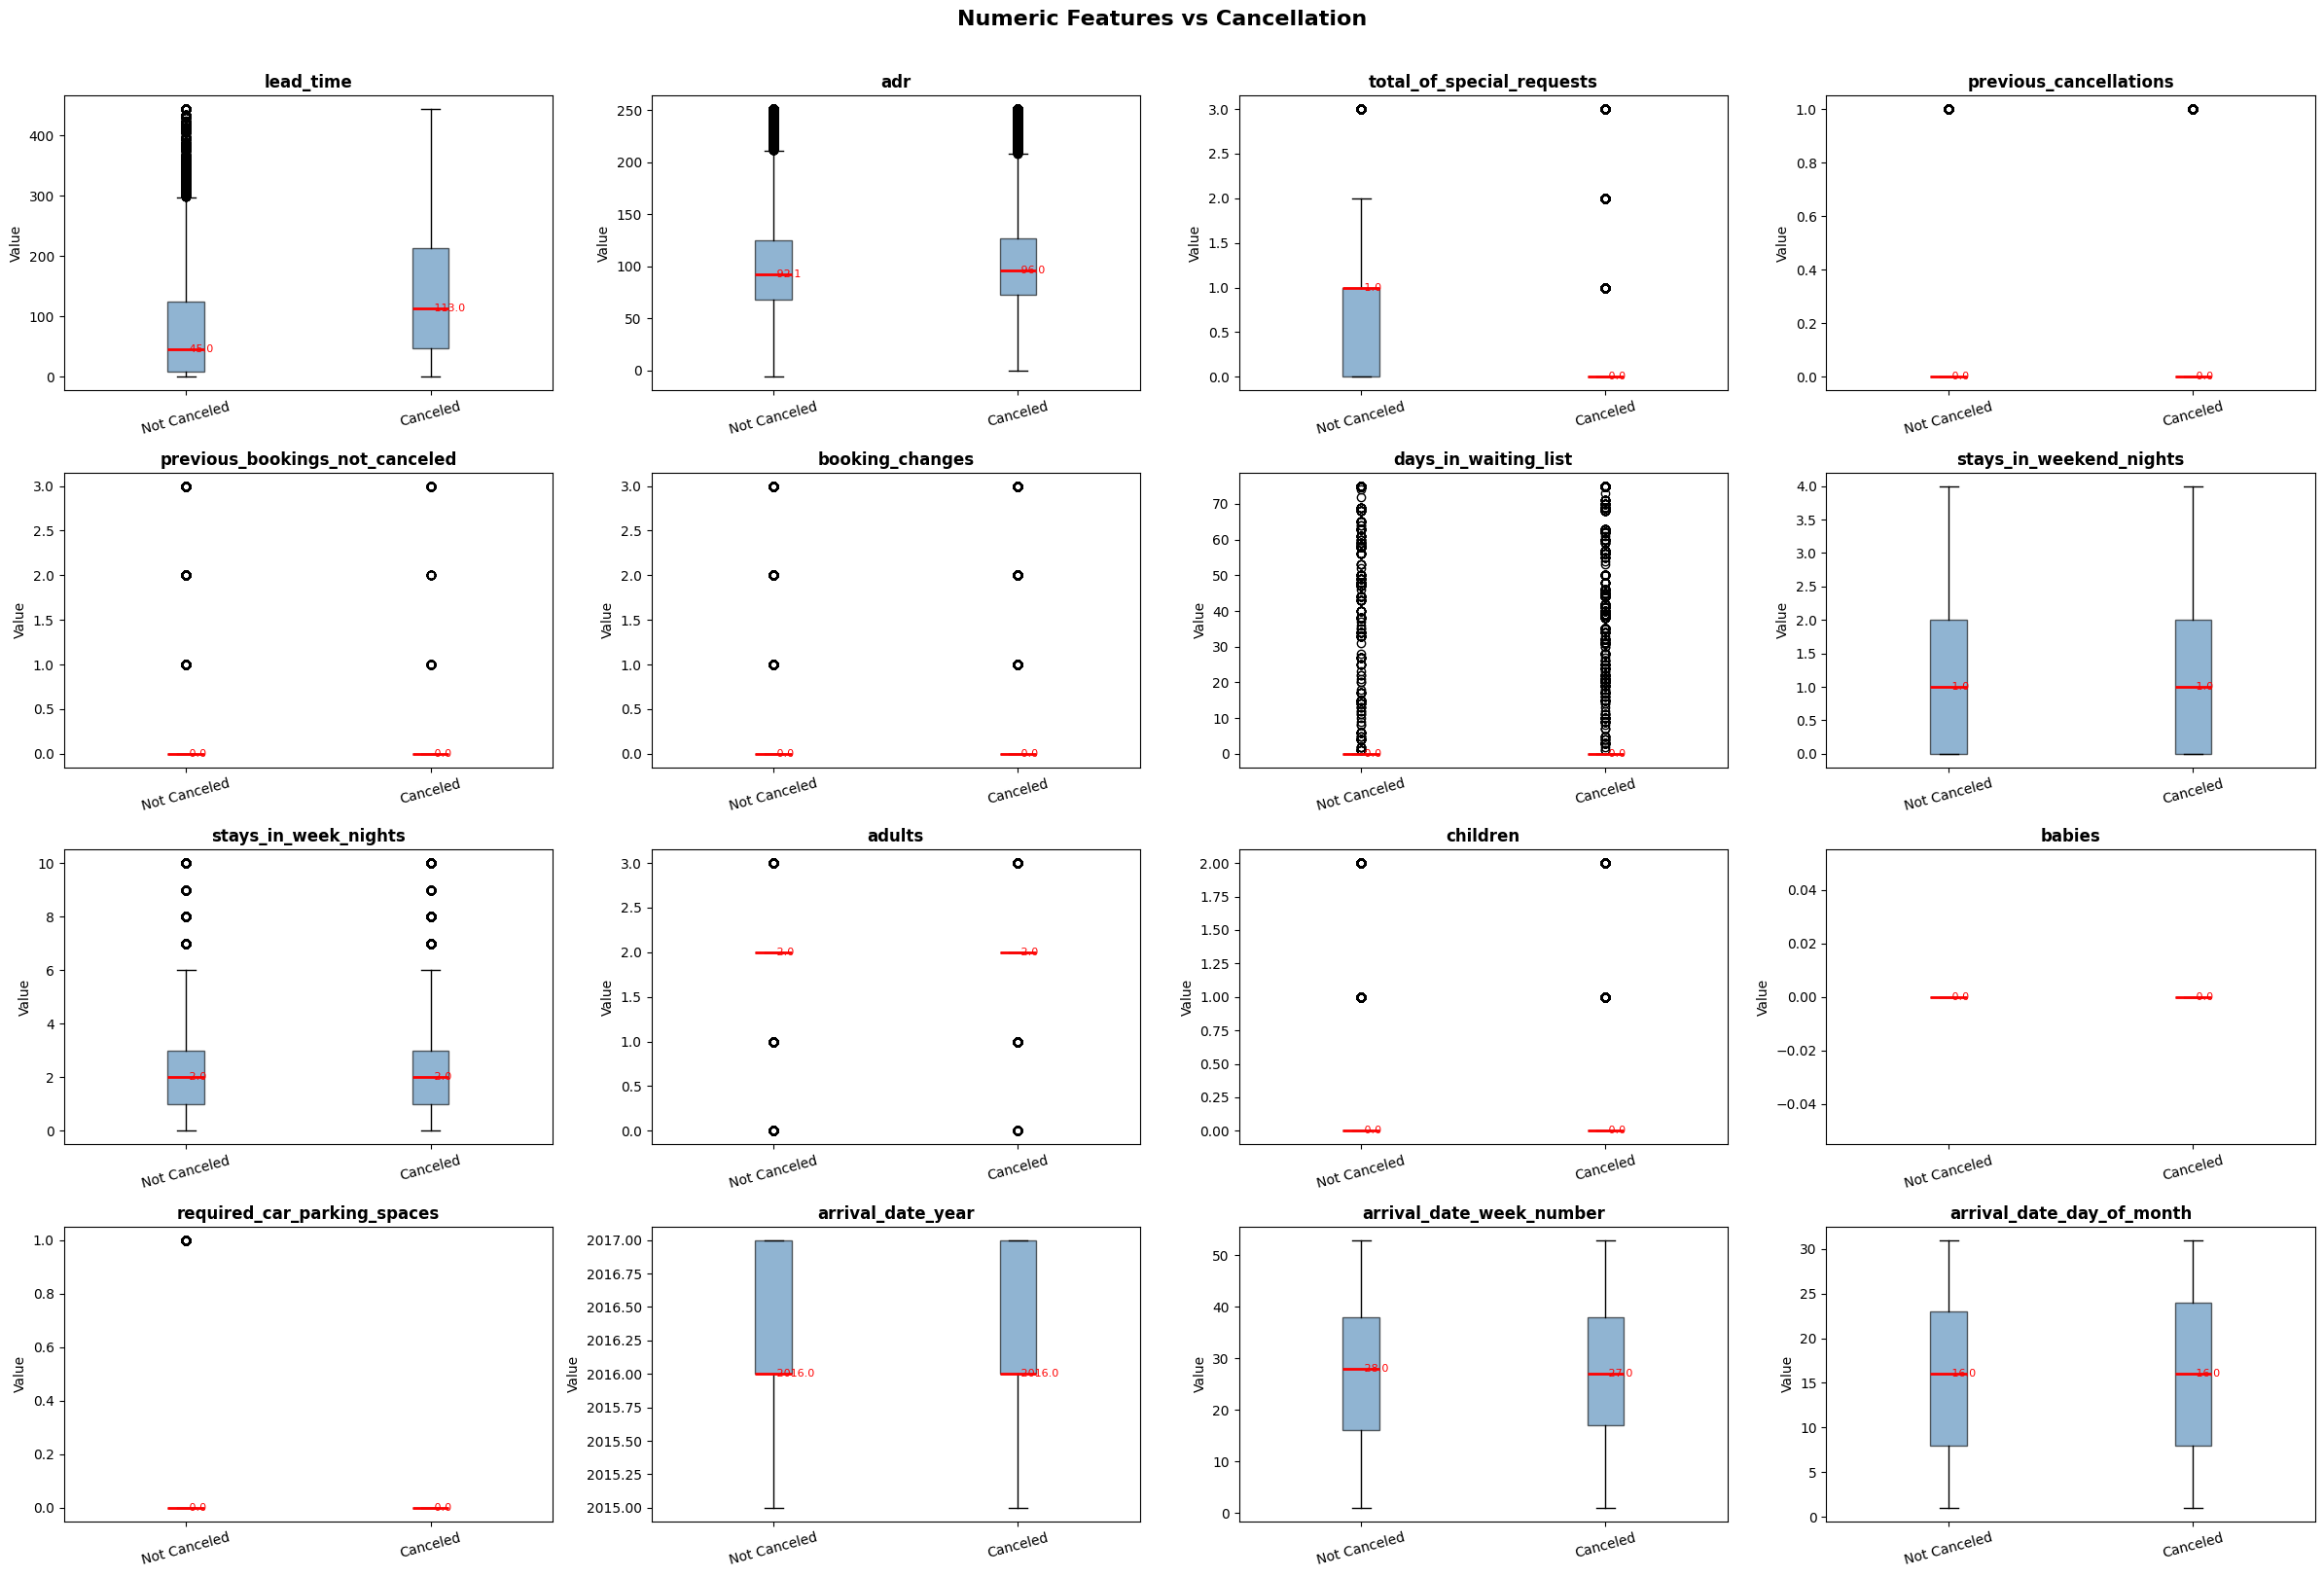

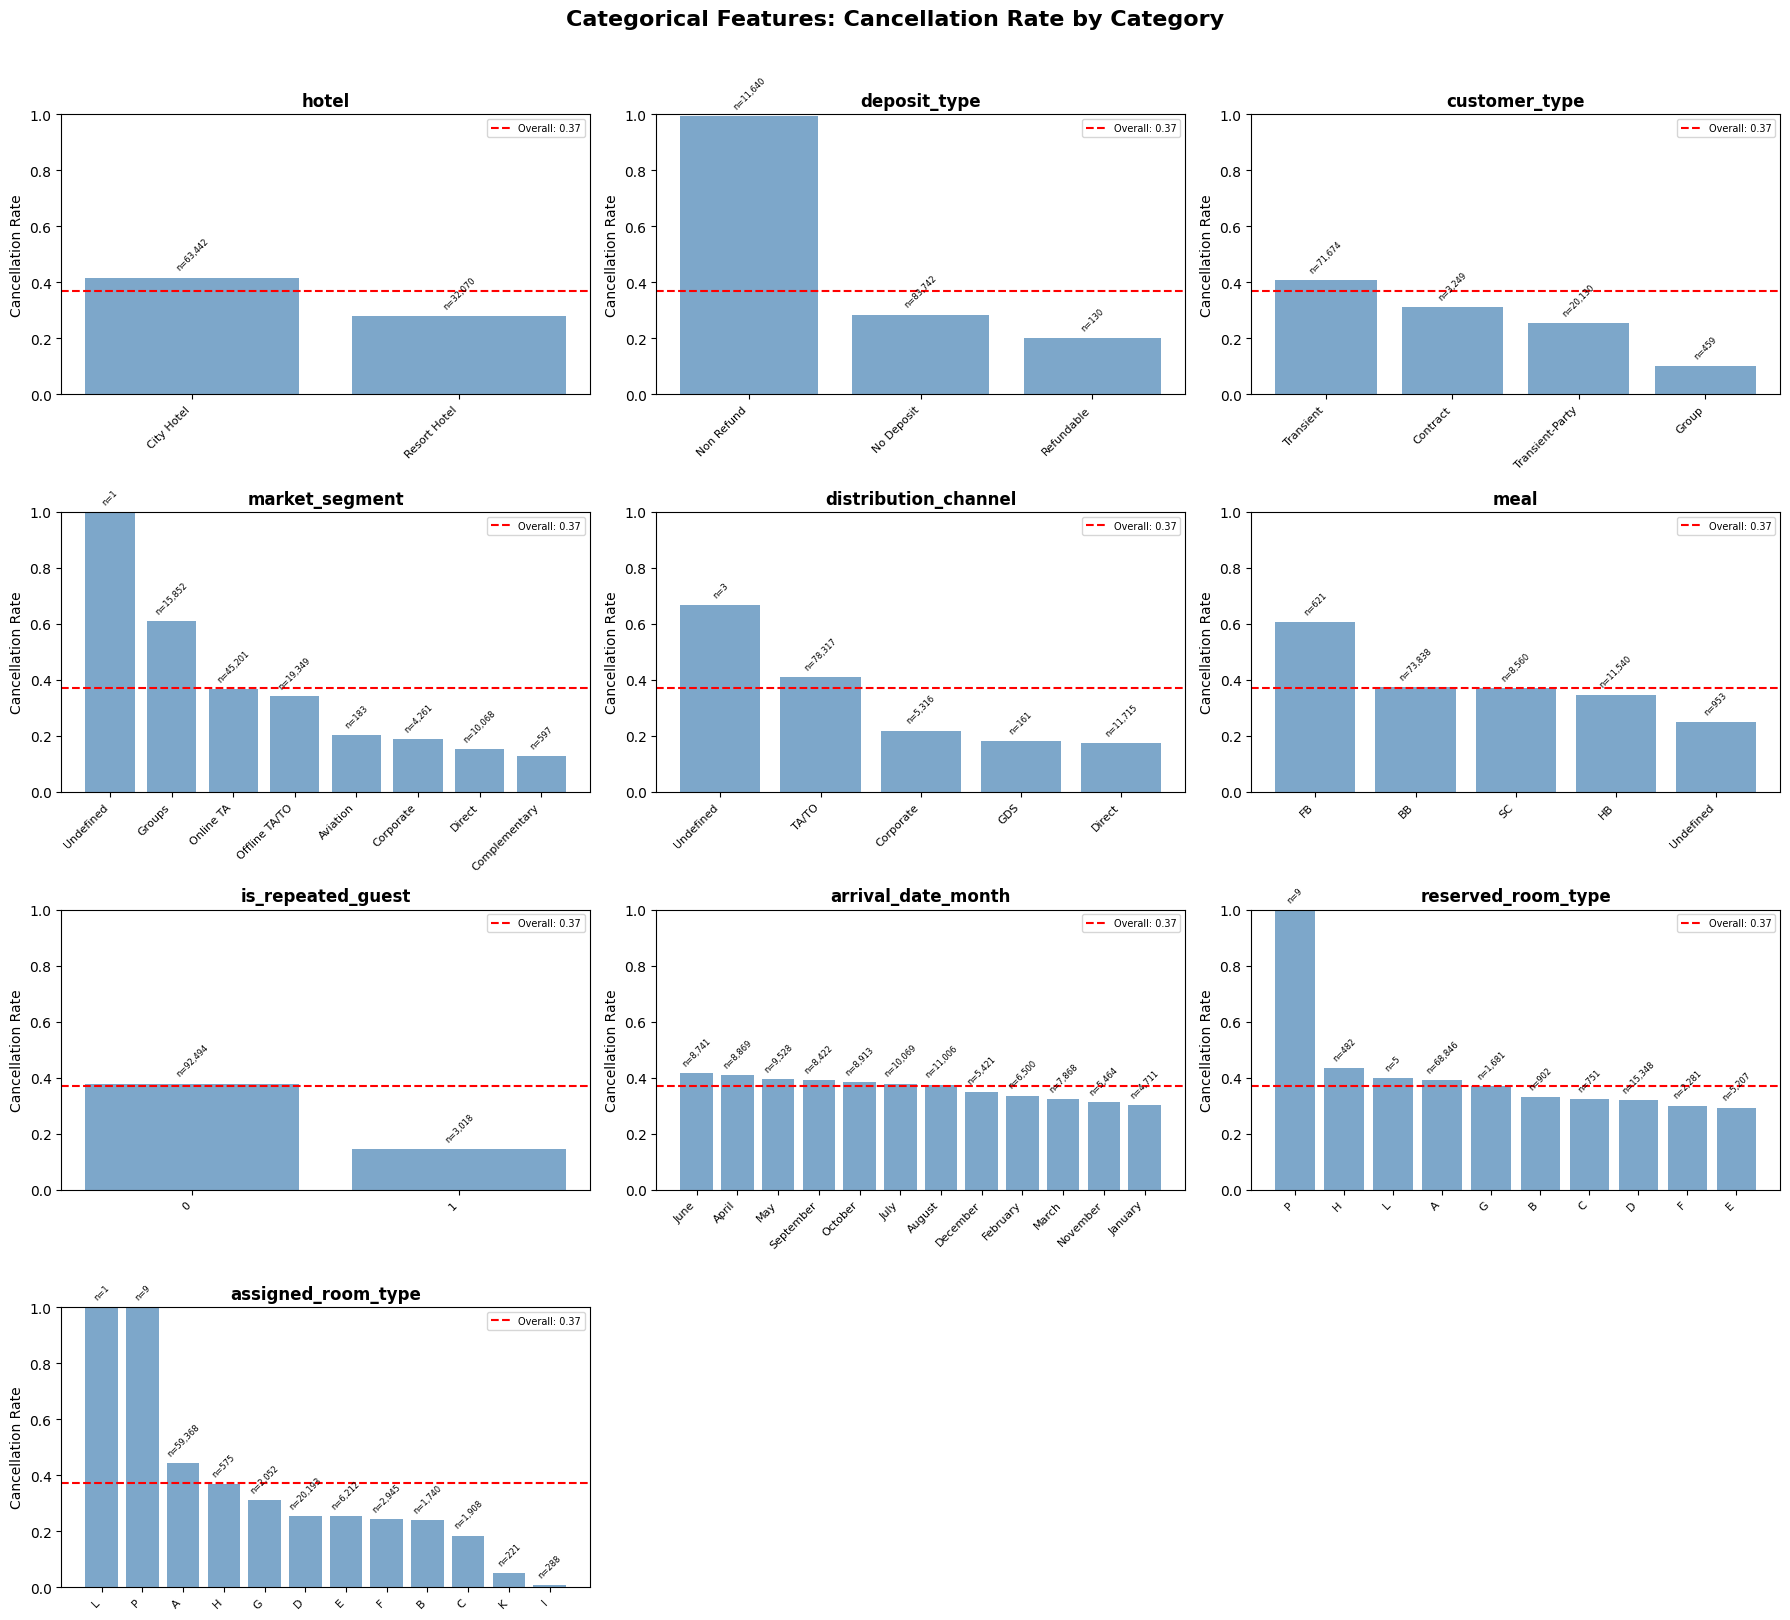

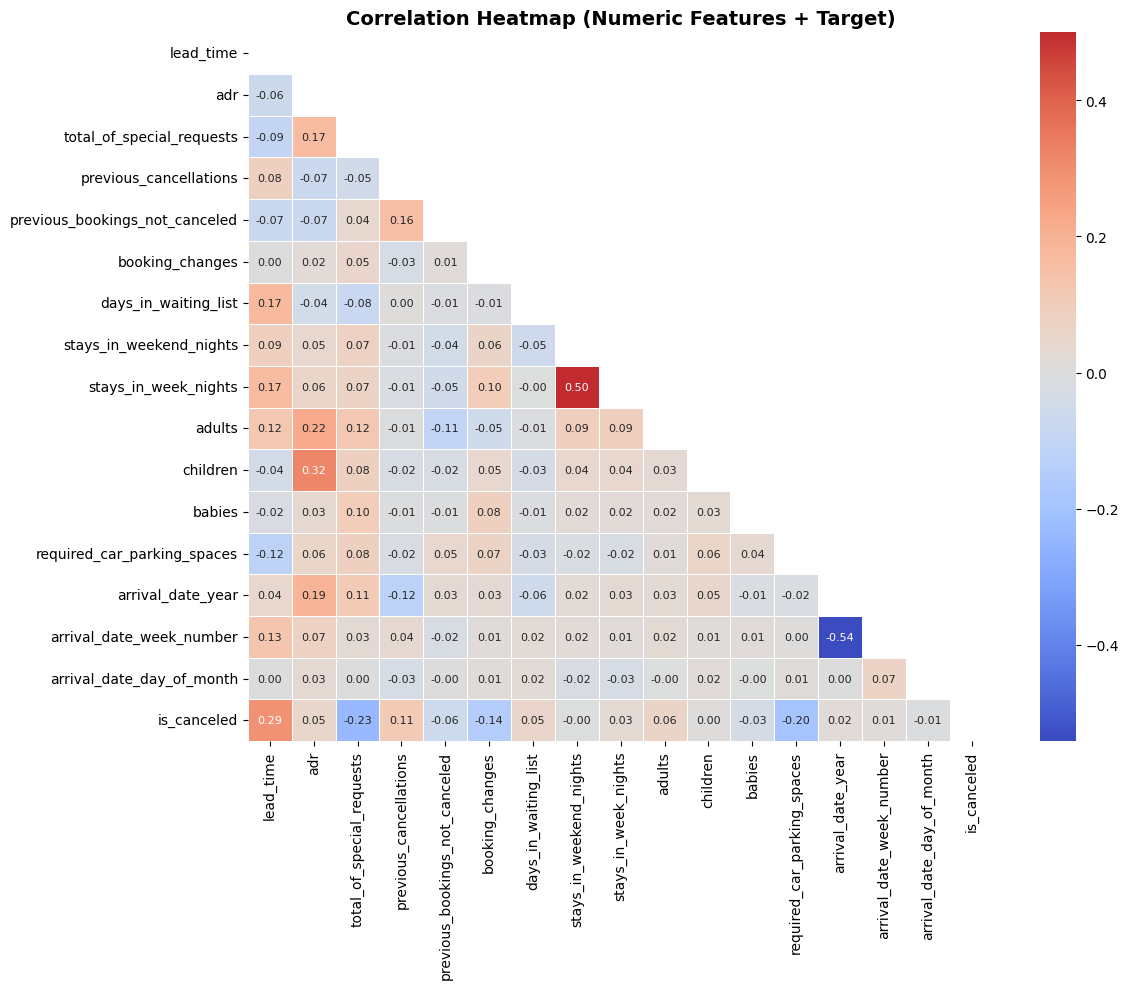


📊 CANCELLATION RATE SUMMARY BY FEATURE

Numeric Feature Medians (Not Canceled vs Canceled):
Feature                                     Not Canceled        Canceled       Diff
--------------------------------------------------------------------------------
lead_time                                          45.00          113.00      68.00 ⬆️
adr                                                92.08           96.00       3.92
total_of_special_requests                           1.00            0.00      -1.00 ⬆️
previous_cancellations                              0.00            0.00       0.00
previous_bookings_not_canceled                      0.00            0.00       0.00
booking_changes                                     0.00            0.00       0.00
days_in_waiting_list                                0.00            0.00       0.00
stays_in_weekend_nights                             1.00            1.00       0.00
stays_in_week_nights                                2.00        

In [6]:
plot_feature_relationships(X_orig_train, y_full_orig)

In [7]:
def record(name, model, train_time, pred_time, y_true, scores):
    auc  = roc_auc_score(y_true, scores)
    ap   = average_precision_score(y_true, scores)
    fpr, tpr, _ = roc_curve(y_true, scores)
    prec, rec, _ = precision_recall_curve(y_true, scores)
    print(f"    AUC={auc:.4f}  AP={ap:.4f}  train={train_time:.1f}s  pred={pred_time:.2f}s")
    results[name] = dict(model=model, scores=scores, auc=auc, ap=ap,
                         train_time=train_time, pred_time=pred_time,
                         fpr=fpr, tpr=tpr, prec=prec, rec=rec)

In [8]:
# ─────────────────────────────────────────
# 2. Feature Engineering  (column-safe)
# ─────────────────────────────────────────
print("\n2. FEATURE ENGINEERING")
print("=" * 65)
 
class FeatureEngineer:
    """
    Fits a column schema on train data, then applies the SAME columns to test.
    Ensures train and test always have identical feature counts.
    """
    def __init__(self, n_ratio_cols=8):
        self.n_ratio_cols  = n_ratio_cols
        self.num_cols_     = None      # numeric column names (fitted)
        self.log_cols_     = None      # cols eligible for log1p
        self.ratio_pairs_  = None      # (c1, c2) pairs for ratios
 
    def fit_transform(self, df):
        df = df.copy()
        self.num_cols_ = df.select_dtypes(include=[np.number]).columns.tolist()
        print(f"  Numeric cols: {len(self.num_cols_)}")
 
        feats = df[self.num_cols_].copy()
 
        # log1p on non-negative columns
        self.log_cols_ = [c for c in self.num_cols_ if feats[c].min() >= 0]
        for col in self.log_cols_:
            feats[f'log1p_{col}'] = np.log1p(feats[col])
 
        # Ratio features — limited to top-N numeric cols
        top = self.num_cols_[:self.n_ratio_cols]
        self.ratio_pairs_ = []
        for i, c1 in enumerate(top):
            for c2 in top[i+1:]:
                self.ratio_pairs_.append((c1, c2))
                denom = feats[c2].replace(0, np.nan)
                feats[f'ratio_{c1}__{c2}'] = feats[c1] / denom
 
        feats = feats.replace([np.inf, -np.inf], np.nan)
        print(f"  Engineered shape: {feats.shape}")
        return feats.values
 
    def transform(self, df):
        """Apply EXACTLY the same columns as fitted — no new columns."""
        df = df.copy()
        feats = df[self.num_cols_].copy()
 
        for col in self.log_cols_:
            feats[f'log1p_{col}'] = np.log1p(feats[col])
 
        for c1, c2 in self.ratio_pairs_:
            denom = feats[c2].replace(0, np.nan)
            feats[f'ratio_{c1}__{c2}'] = feats[c1] / denom
 
        feats = feats.replace([np.inf, -np.inf], np.nan)
        return feats.values
 
 
fe = FeatureEngineer(n_ratio_cols=8)
 
print("  Train feature engineering …")
X_eng_train = fe.fit_transform(X_orig_train)
print("  Test  feature engineering …")
X_eng_test  = fe.transform(X_orig_test)
 
print(f"  eng_train: {X_eng_train.shape}   eng_test: {X_eng_test.shape}")
assert X_eng_train.shape[1] == X_eng_test.shape[1], \
    "BUG: engineered feature count mismatch!"
 
# OHE as numpy
ohe_tr = X_ohe_train.values if hasattr(X_ohe_train, 'values') else np.array(X_ohe_train)
ohe_te = X_ohe_test.values  if hasattr(X_ohe_test,  'values') else np.array(X_ohe_test)
 
# Align OHE columns (test might differ from train)
n_ohe = min(ohe_tr.shape[1], ohe_te.shape[1])
ohe_tr = ohe_tr[:, :n_ohe]
ohe_te = ohe_te[:, :n_ohe]
 
X_combined_train = np.hstack([ohe_tr, X_eng_train])
X_combined_test  = np.hstack([ohe_te, X_eng_test])
print(f"  Combined train: {X_combined_train.shape}")
print(f"  Combined test : {X_combined_test.shape}")
assert X_combined_train.shape[1] == X_combined_test.shape[1], \
    "BUG: combined feature count mismatch!"
 
 


2. FEATURE ENGINEERING
  Train feature engineering …
  Numeric cols: 19
  Engineered shape: (95512, 65)
  Test  feature engineering …
  eng_train: (95512, 65)   eng_test: (23878, 65)
  Combined train: (95512, 1005)
  Combined test : (23878, 1005)


In [9]:
# ─────────────────────────────────────────
# 3. Preprocessing
# ─────────────────────────────────────────
print("\n3. PREPROCESSING")
print("=" * 65)
 
y = y_full_orig.values if hasattr(y_full_orig, 'values') else np.array(y_full_orig)
 
imputer = SimpleImputer(strategy='median')
X_imp   = imputer.fit_transform(X_combined_train)
X_t_imp = imputer.transform(X_combined_test)      # same n_features guaranteed
print(f"  Imputed train: {X_imp.shape}   test: {X_t_imp.shape}")
 
X_tr, X_val, y_tr, y_val = train_test_split(
    X_imp, y, test_size=0.20, random_state=42, stratify=y
)
 
scaler   = RobustScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
X_val_sc = scaler.transform(X_val)
X_t_sc   = scaler.transform(X_t_imp)
 
print(f"  Train {X_tr.shape}  |  Val {X_val.shape}")
neg, pos = np.bincount(y_tr.astype(int))
spw = neg / pos
print(f"  scale_pos_weight = {spw:.2f}")


3. PREPROCESSING
  Imputed train: (95512, 1005)   test: (23878, 1005)
  Train (76409, 1005)  |  Val (19103, 1005)
  scale_pos_weight = 1.70


In [10]:
# ─────────────────────────────────────────
# 4. Models
# ─────────────────────────────────────────
print("\n4. TRAINING MODELS")
print("=" * 65)
 
# 4.1  Logistic Regression  — fast version
print("\n  [Logistic Regression]")
lr = LogisticRegression(
    C=0.1,           # stronger regularization → fewer Newton steps to converge
    max_iter=500,    # lbfgs typically converges in 50-150 iterations
    solver='lbfgs',  # quasi-Newton: converges in ~50 iters vs ~2000 for saga
    n_jobs=-1,
    random_state=42  # no class_weight — C=0.1 provides enough regularization
)
t0=time.time(); lr.fit(X_tr_sc, y_tr); tt=time.time()-t0
t0=time.time(); sc_=lr.predict_proba(X_val_sc)[:,1]; pt=time.time()-t0
record("Logistic Regression", lr, tt, pt, y_val, sc_)


4. TRAINING MODELS

  [Logistic Regression]
    AUC=0.8827  AP=0.8491  train=12.3s  pred=0.02s


In [11]:
# 4.2 KNN
print("\n  [KNN (k=15)]")
knn = KNeighborsClassifier(n_neighbors=15, metric='euclidean', n_jobs=-1)
t0=time.time(); knn.fit(X_tr_sc, y_tr); tt=time.time()-t0
t0=time.time(); sc_=knn.predict_proba(X_val_sc)[:,1]; pt=time.time()-t0
record("KNN (k=15)", knn, tt, pt, y_val, sc_)


  [KNN (k=15)]
    AUC=0.8557  AP=0.8054  train=0.0s  pred=13.13s


In [12]:
# 4.3 Random Forest
print("\n  [Random Forest]")
rf = RandomForestClassifier(n_estimators=600, min_samples_leaf=2,
                             max_features='sqrt',
                             class_weight='balanced_subsample',
                             n_jobs=-1, random_state=42)
t0=time.time(); rf.fit(X_tr, y_tr); tt=time.time()-t0
t0=time.time(); sc_=rf.predict_proba(X_val)[:,1]; pt=time.time()-t0
record("Random Forest", rf, tt, pt, y_val, sc_)


  [Random Forest]
    AUC=0.9505  AP=0.9316  train=30.2s  pred=0.49s


In [13]:
# 4.4 MLP
print("\n  [MLP Neural Net]")
mlp = MLPClassifier(hidden_layer_sizes=(512,256,128,64), activation='relu',
                    solver='adam', alpha=5e-4, learning_rate='adaptive',
                    learning_rate_init=1e-3, max_iter=300, early_stopping=True,
                    validation_fraction=0.1, n_iter_no_change=20, random_state=42)
t0=time.time(); mlp.fit(X_tr_sc, y_tr); tt=time.time()-t0
t0=time.time(); sc_=mlp.predict_proba(X_val_sc)[:,1]; pt=time.time()-t0
record("MLP Neural Net", mlp, tt, pt, y_val, sc_)


  [MLP Neural Net]
    AUC=0.9212  AP=0.8972  train=232.0s  pred=0.16s


In [14]:
# 4.5 XGBoost
print("\n  [XGBoost Tuned]")
xgb_model = None
best_params = {}
try:
    from xgboost import XGBClassifier
 
    if RUN_OPTUNA:
        import optuna
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        def objective(trial):
            p = dict(
                n_estimators     = trial.suggest_int('n_estimators', 400, 1200),
                learning_rate    = trial.suggest_float('lr', 0.01, 0.15, log=True),
                max_depth        = trial.suggest_int('max_depth', 4, 9),
                subsample        = trial.suggest_float('subsample', 0.6, 1.0),
                colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
                min_child_weight = trial.suggest_int('min_child_weight', 1, 20),
                gamma            = trial.suggest_float('gamma', 0, 5),
                reg_alpha        = trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
                reg_lambda       = trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
            )
            idx = np.random.choice(len(X_tr), size=5000, replace=False)
            m = XGBClassifier(**p, scale_pos_weight=spw, use_label_encoder=False,
                              eval_metric='auc', tree_method='hist',
                              random_state=42, n_jobs=-1)
            m.fit(X_tr[idx], y_tr[idx])
            return roc_auc_score(y_val, m.predict_proba(X_val)[:,1])
 
        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=50, show_progress_bar=True)
        best_params = study.best_params
        print(f"    Best Optuna params: {best_params}")
    else:
        best_params = dict(n_estimators=1200, learning_rate=0.03, max_depth=7,
                           subsample=0.85, colsample_bytree=0.75,
                           min_child_weight=5, gamma=0.1,
                           reg_alpha=0.1, reg_lambda=1.0)
 
    xgb_model = XGBClassifier(**best_params, scale_pos_weight=spw,
                              use_label_encoder=False, eval_metric='auc',
                              early_stopping_rounds=50, tree_method='hist',
                              random_state=42, n_jobs=-1)
    t0=time.time()
    xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    tt=time.time()-t0
    t0=time.time(); sc_=xgb_model.predict_proba(X_val)[:,1]; pt=time.time()-t0
    record("XGBoost Tuned", xgb_model, tt, pt, y_val, sc_)
 
except ImportError:
    print("    pip install xgboost")


  [XGBoost Tuned]
    AUC=0.9550  AP=0.9334  train=33.4s  pred=0.06s


In [15]:
# 4.6 LightGBM
print("\n  [LightGBM]")
lgbm_model = None
if USE_LGBM:
    try:
        import lightgbm as lgb
        lgbm_model = lgb.LGBMClassifier(
            n_estimators=1500, learning_rate=0.02, max_depth=8,
            num_leaves=63, subsample=0.85, colsample_bytree=0.75,
            min_child_samples=20, scale_pos_weight=spw,
            reg_alpha=0.1, reg_lambda=1.0,
            random_state=42, n_jobs=-1, verbose=-1
        )
        cbs = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
        t0=time.time()
        lgbm_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=cbs)
        tt=time.time()-t0
        t0=time.time(); sc_=lgbm_model.predict_proba(X_val)[:,1]; pt=time.time()-t0
        record("LightGBM", lgbm_model, tt, pt, y_val, sc_)
    except ImportError:
        print("    install properly")


  [LightGBM]
    AUC=0.9534  AP=0.9312  train=30.7s  pred=0.27s


In [16]:
# 4.7 Stacking
print("\n  [Stacking Ensemble]")
if USE_STACKING:
    base_est = []
    if xgb_model is not None:
        from xgboost import XGBClassifier as XGB2
        base_est.append(('xgb', XGB2(**{k:v for k,v in best_params.items()},
                                     scale_pos_weight=spw, use_label_encoder=False,
                                     eval_metric='auc', tree_method='hist',
                                     random_state=42, n_jobs=-1)))
    if lgbm_model is not None:
        import lightgbm as lgb2
        base_est.append(('lgbm', lgb2.LGBMClassifier(
            n_estimators=800, learning_rate=0.03, max_depth=8, num_leaves=63,
            subsample=0.85, colsample_bytree=0.75, scale_pos_weight=spw,
            random_state=42, n_jobs=-1, verbose=-1)))
    base_est.append(('rf', RandomForestClassifier(
        n_estimators=300, class_weight='balanced_subsample',
        n_jobs=-1, random_state=42)))
 
    if len(base_est) >= 2:
        stack = StackingClassifier(
            estimators=base_est,
            final_estimator=LogisticRegression(C=1.0, max_iter=1000),
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            passthrough=False, n_jobs=1
        )
        t0=time.time(); stack.fit(X_tr, y_tr); tt=time.time()-t0
        t0=time.time(); sc_=stack.predict_proba(X_val)[:,1]; pt=time.time()-t0
        record("Stacking Ensemble", stack, tt, pt, y_val, sc_)
 


  [Stacking Ensemble]
    AUC=0.9591  AP=0.9411  train=247.0s  pred=0.65s


In [17]:
# ─────────────────────────────────────────
# 5. Summary
# ─────────────────────────────────────────
print("\n" + "=" * 65)
print("RESULTS SUMMARY")
print(f"{'Model':<25} {'AUC':>7} {'AP':>7} {'Train(s)':>10} {'Pred(s)':>9}")
print("-" * 65)
for name, r in sorted(results.items(), key=lambda x: -x[1]['auc']):
    print(f"{name:<25} {r['auc']:>7.4f} {r['ap']:>7.4f} "
          f"{r['train_time']:>10.2f} {r['pred_time']:>9.3f}")
best_name = max(results, key=lambda n: results[n]['auc'])
print(f"\nBest: {best_name}  AUC={results[best_name]['auc']:.4f}")


RESULTS SUMMARY
Model                         AUC      AP   Train(s)   Pred(s)
-----------------------------------------------------------------
Stacking Ensemble          0.9591  0.9411     246.98     0.647
XGBoost Tuned              0.9550  0.9334      33.42     0.064
LightGBM                   0.9534  0.9312      30.72     0.273
Random Forest              0.9505  0.9316      30.19     0.488
MLP Neural Net             0.9212  0.8972     232.04     0.161
Logistic Regression        0.8827  0.8491      12.32     0.024
KNN (k=15)                 0.8557  0.8054       0.03    13.133

Best: Stacking Ensemble  AUC=0.9591


In [18]:
# ─────────────────────────────────────────
# 6. Plots
# ─────────────────────────────────────────
COLORS = plt.cm.tab10.colors
names  = list(results.keys())
 
# ROC
fig, ax = plt.subplots(figsize=(9,6))
ax.plot([0,1],[0,1],'k--',lw=1.2,label='Random (AUC = 0.500)')
for i,n in enumerate(names):
    r=results[n]
    ax.plot(r['fpr'],r['tpr'],color=COLORS[i%10],lw=2,
            label=f"{n} (AUC = {r['auc']:.3f})")
ax.set_xlabel("False Positive Rate",fontsize=12)
ax.set_ylabel("True Positive Rate",fontsize=12)
ax.set_title("ROC Curves — Validation Set",fontsize=14,fontweight='bold')
ax.legend(loc='lower right',fontsize=8.5); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig("./plots/roc_curves_v3.png",dpi=150); plt.close()
 
# PR
pos_rate=y_val.mean()
fig,ax=plt.subplots(figsize=(9,6))
ax.axhline(pos_rate,color='k',ls='--',lw=1.2,label=f'Random (AP = {pos_rate:.3f})')
for i,n in enumerate(names):
    r=results[n]
    ax.plot(r['rec'],r['prec'],color=COLORS[i%10],lw=2,
            label=f"{n} (AP = {r['ap']:.3f})")
ax.set_xlabel("Recall",fontsize=12); ax.set_ylabel("Precision",fontsize=12)
ax.set_title("Precision-Recall Curves — Validation Set",fontsize=14,fontweight='bold')
ax.legend(loc='upper right',fontsize=8.5); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig("./plots/pr_curves_v3.png",dpi=150); plt.close()

In [19]:
# Timing
fig,ax=plt.subplots(figsize=(11,5))
x=np.arange(len(names)); w=0.35
b1=ax.bar(x-w/2,[results[n]['train_time'] for n in names],w,label='Train (s)',color='steelblue')
b2=ax.bar(x+w/2,[results[n]['pred_time']  for n in names],w,label='Pred (s)', color='coral')
ax.set_xticks(x); ax.set_xticklabels(names,rotation=22,ha='right',fontsize=9)
ax.set_ylabel("Time (s)",fontsize=12)
ax.set_title("Training & Prediction Time",fontsize=14,fontweight='bold')
ax.legend(); ax.grid(axis='y',alpha=0.3)
for bar in list(b1)+list(b2):
    h=bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.05,
            f'{h:.1f}s',ha='center',va='bottom',fontsize=7)
fig.tight_layout(); fig.savefig("./plots/timing_v3.png",dpi=150); plt.close()
print("Plots saved to ./plots/")

Plots saved to ./plots/


In [20]:
# ─────────────────────────────────────────
# 7. Retrain on ALL data & Submit
# ─────────────────────────────────────────
print("\n7. RETRAINING ON FULL DATA & SUBMISSIONS")
print("=" * 65)
 
import os; os.makedirs("./data", exist_ok=True); os.makedirs("./plots", exist_ok=True)
 
y_all = y_full_orig.values if hasattr(y_full_orig,'values') else np.array(y_full_orig)
neg_all, pos_all = np.bincount(y_all.astype(int))
spw_all = neg_all / pos_all
 
imp_all  = SimpleImputer(strategy='median')
X_all    = imp_all.fit_transform(X_combined_train)
X_t_all  = imp_all.transform(X_combined_test)
 
sc_all      = RobustScaler()
X_all_sc    = sc_all.fit_transform(X_all)
X_t_all_sc  = sc_all.transform(X_t_all)
 
uses_scale = {"Logistic Regression", "KNN (k=15)", "MLP Neural Net"}
 
for name in names:
    r      = results[name]
    model  = r['model']
    scaled = name in uses_scale
    Xf     = X_all_sc if scaled else X_all
    Xt     = X_t_all_sc if scaled else X_t_all
    safe   = name.replace(" ","_").replace("(","").replace(")","").replace("=","")
 
    print(f"\n  [{name}] retraining on full data …")
    if "XGBoost" in name:
        model.set_params(early_stopping_rounds=None)
    t0 = time.time(); model.fit(Xf, y_all); print(f"    {time.time()-t0:.1f}s")
 
    s = model.predict_proba(Xt)[:,1] if hasattr(model,'predict_proba') \
        else model.decision_function(Xt)
    create_submission(s, f"./data/submission_{safe}.csv")
 
print("\nDONE — all submissions in ./data/")


7. RETRAINING ON FULL DATA & SUBMISSIONS

  [Logistic Regression] retraining on full data …
    16.0s
  Saved → ./data/submission_Logistic_Regression.csv

  [KNN (k=15)] retraining on full data …
    0.2s
  Saved → ./data/submission_KNN_k15.csv

  [Random Forest] retraining on full data …
    28.9s
  Saved → ./data/submission_Random_Forest.csv

  [MLP Neural Net] retraining on full data …
    185.0s
  Saved → ./data/submission_MLP_Neural_Net.csv

  [XGBoost Tuned] retraining on full data …
    27.0s
  Saved → ./data/submission_XGBoost_Tuned.csv

  [LightGBM] retraining on full data …
    13.7s
  Saved → ./data/submission_LightGBM.csv

  [Stacking Ensemble] retraining on full data …
    740.9s
  Saved → ./data/submission_Stacking_Ensemble.csv

DONE — all submissions in ./data/
